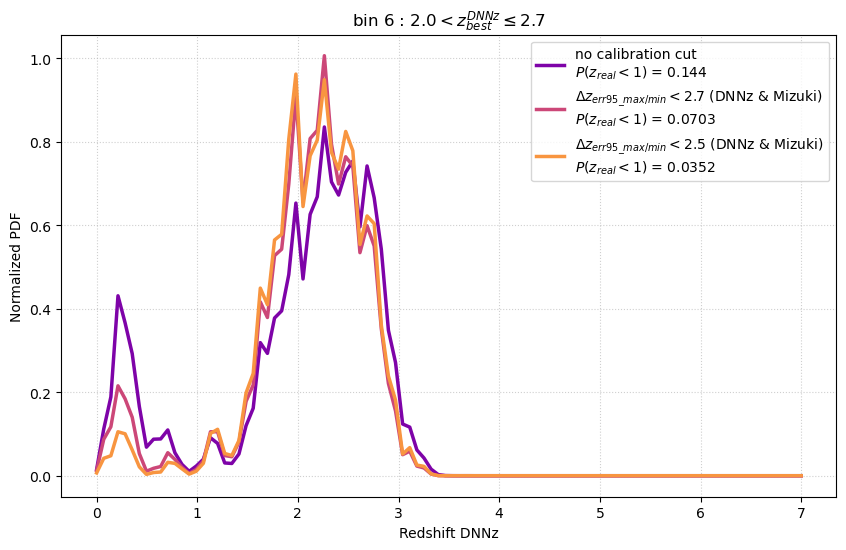

In [1]:
import glob
import os
import fitsio as fio
import matplotlib.pyplot as plt
import numpy as np

# read catalog
cat = "/global/cfs/projectdirs/desi/users/qlavier/desi-y3-hsc/data/hsc/cat/hscy3_cat_withflags.fits" 

with fio.FITS(cat) as hdul:
    # loading useful columns for cuts
    data = hdul[1].read(columns=['object_id', 'dnnz_photoz_err95_max', 'dnnz_photoz_err95_min', 'mizuki_photoz_err95_max', 'mizuki_photoz_err95_min', 'dnnz_photoz_best']) 

plt.figure(figsize=(10, 6))
cmap = plt.get_cmap("plasma")
# different calibration cuts
cuts = [1000, 2.7, 2.5]
for i, cut in enumerate(cuts):
    condition_cut = ((data['dnnz_photoz_best'] > 2.0) &
                     (data['dnnz_photoz_best'] <= 2.7) &
                    (data['dnnz_photoz_err95_max'] - data['dnnz_photoz_err95_min'] < cut) &
                    (data['mizuki_photoz_err95_max'] - data['mizuki_photoz_err95_min'] < cut)
                    )

    ids_select = data['object_id'][condition_cut]

    # improve speed with set()
    set_ids_select = set(ids_select)
    
    # loading PDF files and summing them
    pdf_global_total = np.zeros(100, dtype=np.float64)
    total_galaxies_added = 0
    
    for field in ["GAMA09H", "GAMA15H", "HECTOMAP", "VVDS", "WIDE12H", "XMM"]:
        pattern = f"/global/cfs/cdirs/desicollab/science/c3/DESI-Lensing/prelim_hscy3/gfarm.ipmu.jp/~surhud/S19ACatalogs/catalog_tracts/{field}_tracts/*_pz_pdf_dnnz.fits"
        files = sorted(glob.glob(pattern))

        if not files:
            exit()

        # look at each file and sum the PDFs for selected galaxies
        for file in files:
            name = os.path.basename(file)
            try:
                with fio.FITS(file) as hdul:
                    # read ID and PDF columns
                    try:
                        ids_tract = hdul[1].read(columns='ID')
                        pdf_tract = hdul[1].read(columns='PDF')
                    except ValueError:
                        ids_tract = hdul[1].read(columns='id')
                        pdf_tract = hdul[1].read(columns='pdf')
                    
                    # select galaxies in this file that are in our 'set' of cuts
                    mask_in_select = np.isin(ids_tract, list(set_ids_select))
                    
                    # if there are matching objects, extract and sum
                    nb_objects_found = np.sum(mask_in_select)
                    if nb_objects_found > 0:
                        # nansum to avoid NaN issues
                        sum_files_found = np.nansum(pdf_tract[mask_in_select], axis=0)
                        
                        pdf_global_total += sum_files_found
                        total_galaxies_added += nb_objects_found
                        
            except Exception as e:
                print(f" -> Error when reading {name} : {e}")

    # plot the combined PDF for this cut
    if total_galaxies_added > 0:
        
        redshifts = np.linspace(0, 7, 100)
        delta_z = 7 / 99
        
        # security against NaN for plotting
        y_plot_cut = np.nan_to_num(pdf_global_total)
        
        # normalization to probability density (Area = 1)
        area_under_curve = np.sum(y_plot_cut) * delta_z
        pdf_normalised = y_plot_cut / area_under_curve
        
        probability_below_1 = np.sum(y_plot_cut[redshifts < 1.0] * delta_z / area_under_curve)
        if cut == 1000:
            plt.plot(redshifts, pdf_normalised, color = cmap(float((i+1)/(len(cuts)+1))), lw=2.5, label=fr"no calibration cut" + '\n' + fr"$P(z_{{real}} < 1)$ = {probability_below_1:.3g}")
        else:
            plt.plot(redshifts, pdf_normalised, color = cmap(float((i+1)/(len(cuts)+1))), lw=2.5, label=fr"$\Delta z_{{err95\_max/min}} < {cut}$ (DNNz & Mizuki)"  + '\n' + fr"$P(z_{{real}} < 1)$ = {probability_below_1:.3g}")
            
plt.xlabel('Redshift DNNz')
plt.ylabel('Normalized PDF')
plt.title(fr"bin 6 : $2.0 < z_{{best}}^{{DNNz}} \leq 2.7$")
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper right')
plt.savefig("/global/cfs/projectdirs/desi/users/qlavier/desi-y3-hsc/src/statistics/scripts_nz/paper_figs/pdf_bin6_calibration_cuts.png", dpi=300)
plt.show()